In [1]:
import numpy as np
from sklearn.decomposition import PCA, TruncatedSVD
import matplotlib.pyplot as plt
import plotly.graph_objects as go

## Task 1 One-hot encoding of protein sequences

The protein sequences are provided as aligned strings of amino acids. Since
machine learning models require numerical inputs, I first need to convert each
sequence into a numerical representation.

I use a simple one-hot encoding scheme: each amino acid is mapped to a
20-dimensional binary vector, while the gap symbol '-' is mapped to the zero
vector. For a sequence of length L, this results in a vector of size 20xL.

This representation is straightforward and preserves positional information
along the sequence alignment

In [2]:
def ohe(seqs):
    alphabet = "ACDEFGHIKLMNPQRSTVWY-"
    char_to_int = {c: i for i, c in enumerate(alphabet)}

    N = len(seqs)
    L = len(seqs[0])
    D = len(alphabet)

    X = np.zeros((N, L, D))

    for i, seq in enumerate(seqs):
        for j, aa in enumerate(seq):
            if aa in char_to_int:
                X[i, j, char_to_int[aa]] = 1.0

    return X.reshape(N, L * D)

### Reading the file and performing OHE

I now load the aligned protein sequences, extract the functional labels from the
headers, and then apply the one-hot encoding defined above.

In [3]:
import os
os.chdir("/Users/pietroscapolo/Library/CloudStorage/OneDrive-PolitecnicodiTorino/PCS/Paris/Computational Science/Project")

In [4]:
from Bio import SeqIO
import numpy as np

def load_fasta_and_ohe(
    fasta_path,
    with_labels=True,
    label_keyword="functional_true"
):
    """
    Load aligned protein sequences from a FASTA file and apply one-hot encoding.

    Parameters
    ----------
    fasta_path : str
        Path to FASTA file.
    with_labels : bool
        Whether to extract functional labels from the description.
    label_keyword : str
        Keyword identifying functional sequences.

    Returns
    -------
    X : np.ndarray
        One-hot encoded sequences, shape (N, 20*L).
    labels : np.ndarray or None
        Binary labels (1=functional, 0=non-functional), or None if not requested.
    sequences : list of str
        Raw sequence strings.
    """

    sequences = []
    labels = []

    for record in SeqIO.parse(fasta_path, "fasta"):
        sequences.append(str(record.seq))
        if with_labels:
            labels.append(1 if label_keyword in record.description else 0)

    X = ohe(sequences)

    if with_labels:
        labels = np.array(labels)
    else:
        labels = None

    print(f"Loaded {len(sequences)} sequences from {fasta_path}")
    print("Encoded dataset shape:", X.shape)

    return X, labels, sequences

X_nat, labels_nat, seqs_nat = load_fasta_and_ohe(
    "data/MSA_nat.faa",
    with_labels=True
)

X_art, labels_art, seqs_art = load_fasta_and_ohe(
    "data/MSA_art.faa",
    with_labels=True
)

Loaded 1130 sequences from data/MSA_nat.faa
Encoded dataset shape: (1130, 2016)
Loaded 1003 sequences from data/MSA_art.faa
Encoded dataset shape: (1003, 2016)


Before moving on, I quickly check how functional and non-functional sequences
are distributed in the dataset.

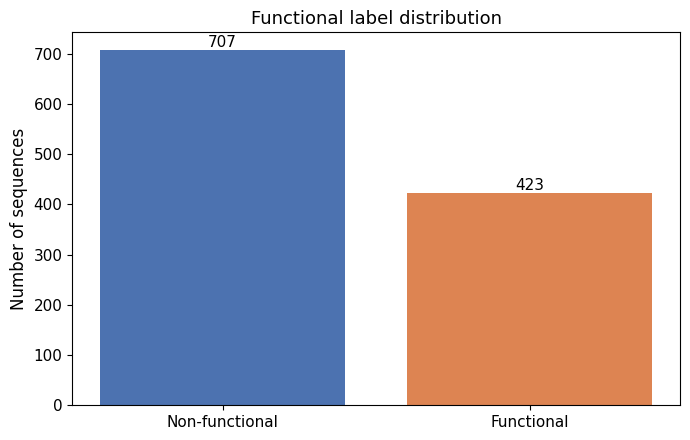

In [5]:
import numpy as np

labels_unique, labels_counts = np.unique(labels_nat, return_counts=True)

plt.figure(figsize=(7, 4.5))

plt.bar(
    ["Non-functional", "Functional"],
    labels_counts,
    color=["#4C72B0", "#DD8452"]
)

plt.ylabel("Number of sequences", fontsize=12)
plt.title("Functional label distribution", fontsize=13)

plt.text(0, labels_counts[0], labels_counts[0],
         ha="center", va="bottom", fontsize=11)
plt.text(1, labels_counts[1], labels_counts[1],
         ha="center", va="bottom", fontsize=11)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

# Task 2 – Dimensional reduction and visualization of sequence space

After encoding the protein sequences, each sequence lives in a very
high-dimensional space (20xL dimensions). To build some intuition about the
structure of the dataset, I now use dimensionality reduction methods as
exploratory tools.

The goal here is not prediction, but visualization: I want to see how sequences
are distributed in sequence space and whether functional and non-functional
proteins show any visible structure. All methods are unsupervised, and labels
are only used afterwards to interpret the results.

## Principal Component Analysis (PCA)

I start with PCA, a linear dimensionality reduction method that identifies
directions in feature space along which the data show the largest variance.

Here, PCA is used only for visualization. The decomposition is computed without
using any label information, which is introduced only afterwards to interpret
the projections.

I first project the sequences onto the first two principal components to get a
global view of the sequence space.

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def plot_pca_artificial_on_natural(
    X_nat,
    labels_nat,
    X_other,
    labels_other,
    pca,
    title,
    figsize=(7.5, 5),
):
    """
    Plot natural sequences as background and project other sequences
    (artificial / generated) onto the PCA space learned from natural data.
    """

    # Project both datasets
    X_nat_pca = pca.transform(X_nat)
    X_other_pca = pca.transform(X_other)

    plt.figure(figsize=figsize)

    # --- Natural background ---
    plt.scatter(
        X_nat_pca[:, 0],
        X_nat_pca[:, 1],
        s=10,
        alpha=0.25,
        color="gray",
        label="Natural",
    )

    # --- Overlay (artificial / generated) ---
    plt.scatter(
        X_other_pca[labels_other == 0, 0],
        X_other_pca[labels_other == 0, 1],
        s=18,
        alpha=0.7,
        label="Non-functional (artificial)",
    )
    plt.scatter(
        X_other_pca[labels_other == 1, 0],
        X_other_pca[labels_other == 1, 1],
        s=18,
        alpha=0.7,
        label="Functional (artificial)",
    )

    plt.xlabel(
        f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)",
        fontsize=12,
    )
    plt.ylabel(
        f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)",
        fontsize=12,
    )

    plt.title(title, fontsize=13)
    plt.legend(frameon=False, fontsize=11)
    plt.tight_layout()
    plt.show()

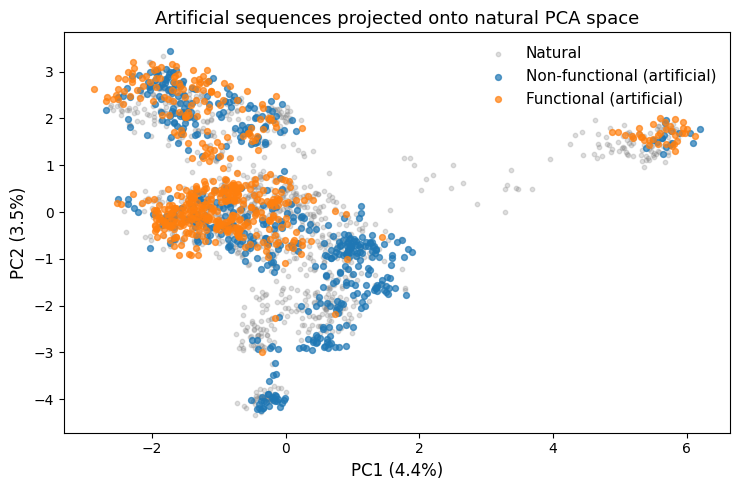

In [7]:
from sklearn.decomposition import PCA

# PCA learned ONLY on natural data
pca = PCA(n_components=2)
pca.fit(X_nat)

# Plot artificial sequences in natural space
plot_pca_artificial_on_natural(
    X_nat,
    labels_nat,
    X_art,
    labels_art,
    pca,
    title="Artificial sequences projected onto natural PCA space",
)

In this projection, functional and non-functional sequences largely overlap,
suggesting that the main directions of variance are not directly related to
functionality.

To better understand how variance is distributed across components, I also look
at the explained variance spectrum.

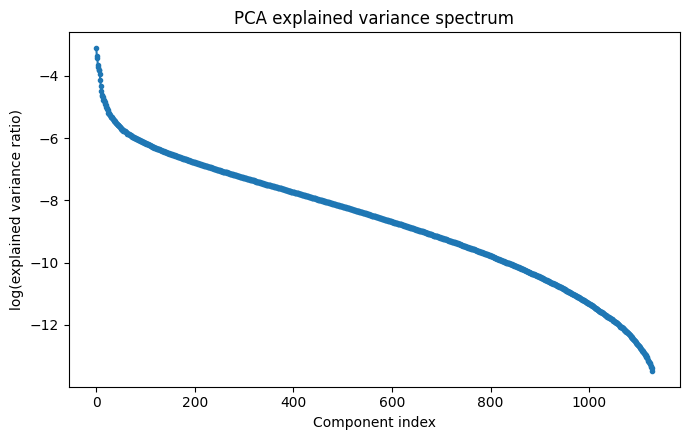

In [8]:
pca_full = PCA()
pca_full.fit(X_nat)

plt.figure(figsize=(7, 4.5))
plt.plot(np.log(pca_full.explained_variance_ratio_[:-1]), marker="o", markersize=3)

plt.xlabel("Component index")
plt.ylabel("log(explained variance ratio)")
plt.title("PCA explained variance spectrum")

plt.tight_layout()
plt.show()

Variance is distributed across many components, indicating a highly complex sequence space.


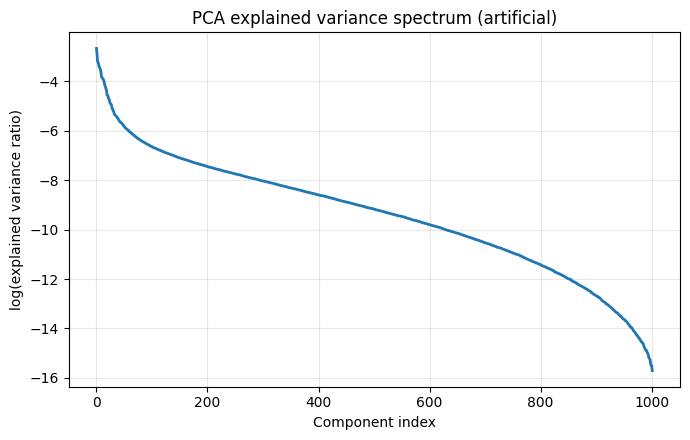

In [9]:
pca_art = PCA()
pca_art.fit(X_art)

plt.figure(figsize=(7, 4.5))
plt.plot(
    np.log(pca_art.explained_variance_ratio_[:-1]),
    linewidth=2
)

plt.xlabel("Component index")
plt.ylabel("log(explained variance ratio)")
plt.title("PCA explained variance spectrum (artificial)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Generated sequences exhibit a comparable variance spectrum, suggesting preserved global complexity.

## t-distributed Stochastic Neighbor Embedding (t-SNE)

To further explore the structure of the sequence space, I now use t-SNE, a
non-linear dimensionality reduction method designed for visualization.

Unlike PCA and Truncated SVD, t-SNE focuses on preserving local neighborhood
relationships rather than global geometry. For this reason, it is used here
only as a qualitative tool.

In [10]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    random_state=69,
)

X_tsne = tsne.fit_transform(X_nat)

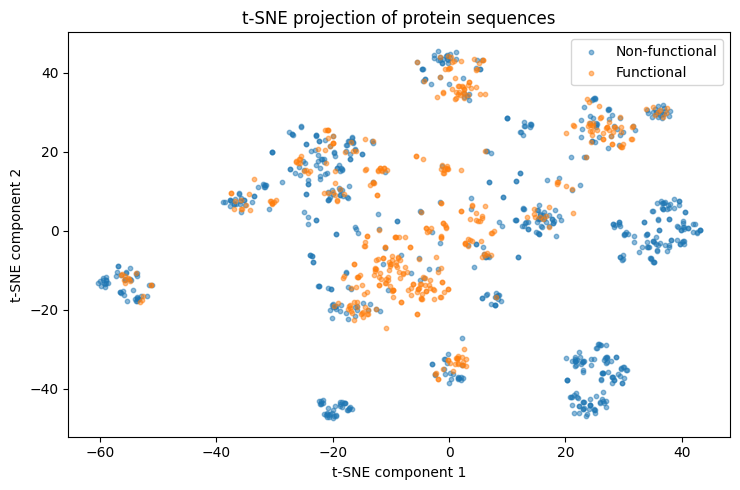

In [11]:
plt.figure(figsize=(7.5, 5))

plt.scatter(
    X_tsne[labels_nat == 0, 0],
    X_tsne[labels_nat == 0, 1],
    s=10,
    alpha=0.5,
    label="Non-functional"
)

plt.scatter(
    X_tsne[labels_nat == 1, 0],
    X_tsne[labels_nat == 1, 1],
    s=10,
    alpha=0.5,
    label="Functional"
)

plt.xlabel("t-SNE component 1")
plt.ylabel("t-SNE component 2")
plt.title("t-SNE projection of protein sequences")
plt.legend()
plt.tight_layout()
plt.show()

In the t-SNE embedding, functional and non-functional sequences remain largely mixed, with no clear global separation. Some local groupings are visible, but they do not correspond to well-defined functional clusters. Since t-SNE strongly depends on hyperparameters and does not preserve global distances, this visualization should be interpreted with caution. Overall, the t-SNE visualization is consistent with the linear methods and does not reveal a clear functional organization in the sequence space.

# Task 3 – Unsupervised clustering of protein sequences

In this task, I apply unsupervised clustering methods to investigate whether
protein sequences naturally organize into groups based on sequence similarity.

Clustering is performed without using functional labels, which are introduced
only afterwards to assess whether cluster membership correlates with
functionality. The goal is not to find an optimal partition, but to understand
whether the structure of sequence space reflects functional organization.

**Clustering strategies**

To explore the structure of the sequence space, I consider two complementary
clustering approaches.

First, I apply k-means clustering, a centroid-based method that partitions
the data into a fixed number of clusters by minimizing the within-cluster
variance. This method provides a simple and intuitive baseline, but requires
the number of clusters to be specified in advance.

Second, I use hierarchical clustering, which builds a tree-like structure
(dendrogram) based on pairwise distances between sequences. This approach
does not require fixing the number of clusters a priori and allows inspection
of the clustering structure at multiple scales.

By comparing the results obtained with these two methods, I aim to assess
the robustness of the observed clustering patterns and their possible
relation to protein functionality.

## K-means clustering

As a first clustering approach, I apply k-means to the one-hot encoded protein
sequences. Clustering is performed in the original high-dimensional space, while
results are visualized by projecting the data onto the first two principal
components.

In [12]:
from sklearn.cluster import KMeans

n_clusters = 7

kmeans = KMeans(n_clusters=n_clusters, random_state=69, n_init="auto")
cluster_labels = kmeans.fit_predict(X_nat)

func_mask = labels_nat == 1
non_func_mask = labels_nat == 0

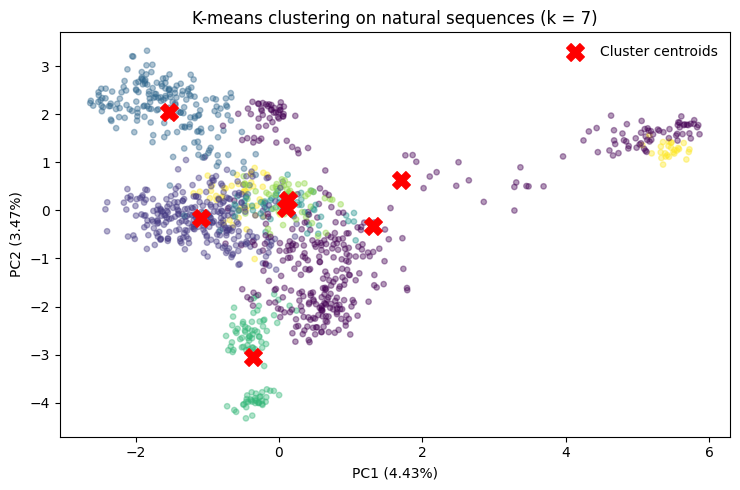

In [13]:
pca = PCA(n_components=2)
X_nat_pca = pca.fit_transform(X_nat)

# Project KMeans centroids into PCA space (natural PCA)
centroids_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(7.5, 5))

# Natural sequences in PCA space
plt.scatter(
    X_nat_pca[:, 0],
    X_nat_pca[:, 1],
    c=cluster_labels,
    cmap="viridis",
    s=15,
    alpha=0.4,
)

# Cluster centroids
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    facecolors="red",
    s=160,
    marker="X",
    linewidths=1,
    label="Cluster centroids",
)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")
plt.title(f"K-means clustering on natural sequences (k = {n_clusters})")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

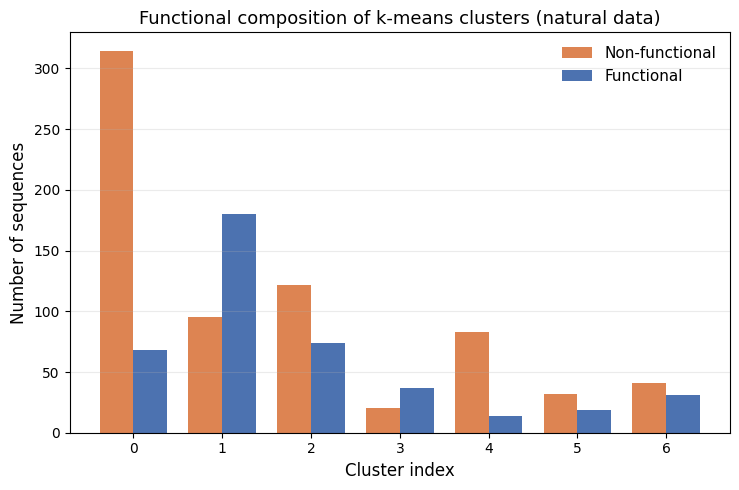

In [14]:
import numpy as np
import matplotlib.pyplot as plt

counts_func = []
counts_non = []

for c in range(n_clusters):
    mask = cluster_labels == c
    counts_func.append(np.sum(labels_nat[mask] == 1))
    counts_non.append(np.sum(labels_nat[mask] == 0))

clusters = np.arange(n_clusters)
width = 0.38

plt.figure(figsize=(7.5, 5))

plt.bar(
    clusters - width / 2,
    counts_non,
    width=width,
    color="#DD8452",
    label="Non-functional",
)

plt.bar(
    clusters + width / 2,
    counts_func,
    width=width,
    color="#4C72B0",
    label="Functional",
)

plt.xlabel("Cluster index", fontsize=12)
plt.ylabel("Number of sequences", fontsize=12)
plt.title("Functional composition of k-means clusters (natural data)", fontsize=13)

plt.xticks(clusters)
plt.legend(frameon=False, fontsize=11)
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

In the PCA projection, clusters occupy overlapping regions of the sequence
space. Functional and non-functional sequences are strongly mixed, with no clear
separation based on functionality.

In [15]:
print(f"{'Cluster':<8} | {'Total':<8} | {'Functional':<12} | {'Non-functional':<15}")
print("-" * 55)

for c in range(n_clusters):
    mask = cluster_labels == c
    total = mask.sum()
    n_func = np.sum(labels_nat[mask] == 1)
    n_non = np.sum(labels_nat[mask] == 0)

    print(f"{c:<8} | {total:<8} | {n_func:<12} | {n_non:<15}")

Cluster  | Total    | Functional   | Non-functional 
-------------------------------------------------------
0        | 382      | 68           | 314            
1        | 275      | 180          | 95             
2        | 196      | 74           | 122            
3        | 57       | 37           | 20             
4        | 97       | 14           | 83             
5        | 51       | 19           | 32             
6        | 72       | 31           | 41             


Each cluster contains a mixture of functional and non-functional sequences,
confirming that k-means does not reveal a clear functional organization of the
data.

### Choosing the number of clusters: the elbow method

Since k-means requires specifying the number of clusters, I briefly inspect the
elbow curve to understand how the within-cluster variance changes with K.

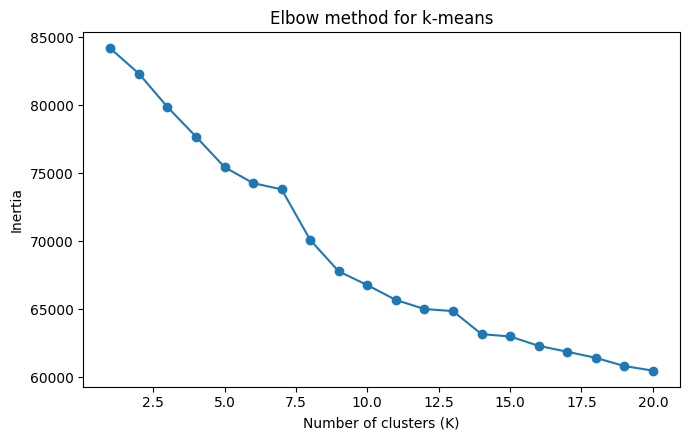

In [16]:
max_clusters = 20
K_values = range(1, max_clusters + 1)
inertias = []

for k in K_values:
    model = KMeans(n_clusters=k, random_state=69, n_init="auto")
    model.fit(X_nat)
    inertias.append(model.inertia_)

plt.figure(figsize=(7, 4.5))
plt.plot(K_values, inertias, marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow method for k-means")
plt.tight_layout()
plt.show()

The inertia decreases smoothly as K increases, without a clear elbow. This
suggests that the data do not exhibit a natural partition into a small number of
compact clusters, and that the choice of K remains heuristic.

### Clustering stability across random initializations (ARI)

To assess how stable the clustering is with respect to initialization, I
compute the Adjusted Rand Index (ARI) across different random seeds.

In [17]:
from sklearn.metrics import adjusted_rand_score
import pandas as pd

Ks = range(2, 21)
random_states = range(50, 80)

rows = []

for k in Ks:
    km_ref = KMeans(n_clusters=k, random_state=0, n_init="auto")
    labels_ref = km_ref.fit_predict(X_nat)

    for rs in random_states:
        km = KMeans(n_clusters=k, random_state=rs, n_init="auto")
        labels_rs = km.fit_predict(X_nat)
        ari = adjusted_rand_score(labels_ref, labels_rs)
        rows.append({"K": k, "ARI": ari})

df_ari = pd.DataFrame(rows)
summary = df_ari.groupby("K")["ARI"].agg(["mean", "std"]).reset_index()

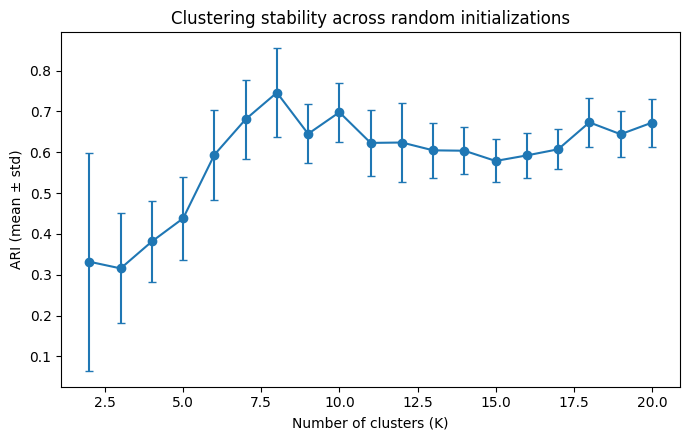

In [18]:
plt.figure(figsize=(7, 4.5))
plt.errorbar(
    summary["K"],
    summary["mean"],
    yerr=summary["std"],
    marker="o",
    capsize=3,
)
plt.xlabel("Number of clusters (K)")
plt.ylabel("ARI (mean ± std)")
plt.title("Clustering stability across random initializations")
plt.tight_layout()
plt.show()

From this plot, I see that the stability of the clustering depends on the number
of clusters K. For small values of K, the ARI is relatively low and varies
significantly across different random initializations, indicating that the
resulting partitions are not very stable.

As K increases, the average ARI tends to increase and the variability decreases,
suggesting that the clustering becomes more stable. However, this improved
stability does not correspond to a clearer separation between functional and
non-functional sequences, but rather to a finer subdivision of the data.

Overall, this suggests that k-means can produce stable clusterings for larger
values of K, but the data do not show a strong intrinsic cluster structure that
is clearly related to protein functionality.

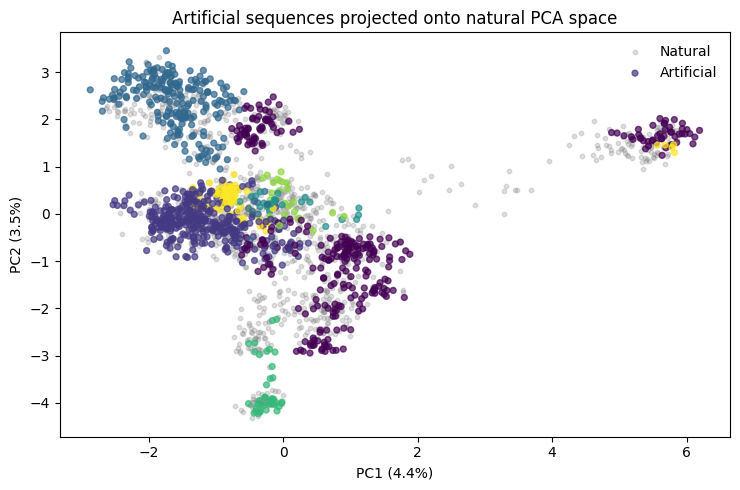

In [19]:
# Fit PCA on natural sequences
pca = PCA(n_components=2)
X_nat_pca = pca.fit_transform(X_nat)

# Project artificial sequences onto PCA space learned from natural data
X_art_pca = pca.transform(X_art)

# Assign artificial sequences to natural clusters
labels_art_clusters = kmeans.predict(X_art)

plt.figure(figsize=(7.5, 5))

# Natural sequences (background)
plt.scatter(
    X_nat_pca[:, 0],
    X_nat_pca[:, 1],
    s=10,
    alpha=0.25,
    color="gray",
    label="Natural",
)

# Artificial sequences (colored by natural clusters)
plt.scatter(
    X_art_pca[:, 0],
    X_art_pca[:, 1],
    c=labels_art_clusters,
    cmap="viridis",
    s=18,
    alpha=0.7,
    label="Artificial",
)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("Artificial sequences projected onto natural PCA space")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

To understand how the artificial sequences relate to the natural ones, I projected them onto the PCA space learned from the natural dataset.

What is interesting is that the artificial sequences do not appear in completely new regions of the space. Instead, they mostly fall inside the same clouds defined by the natural data and align well with the existing cluster structure.

At the same time, artificial sequences tend to fill the clusters more homogeneously and sometimes reach the edges of the natural distribution. This suggests that the generative model is not simply memorizing the training data, but is exploring nearby regions of sequence space while remaining consistent with the global geometry learned from natural sequences.

## Density-based clustering with DBSCAN

To complement k-means clustering, I also consider DBSCAN, a density-based
clustering algorithm. DBSCAN groups together points that lie in dense regions
of the feature space and labels isolated points as noise.

The method is controlled by two parameters: a distance scale ε defining the
neighborhood of each point, and a minimum number of neighbors required to
form a dense region. Unlike k-means, DBSCAN does not require the number of
clusters to be specified in advance.

In this analysis, DBSCAN is applied to the two-dimensional PCA projection of
the data. This allows the algorithm to operate in a low-dimensional space
where distances are easier to interpret and visualize.

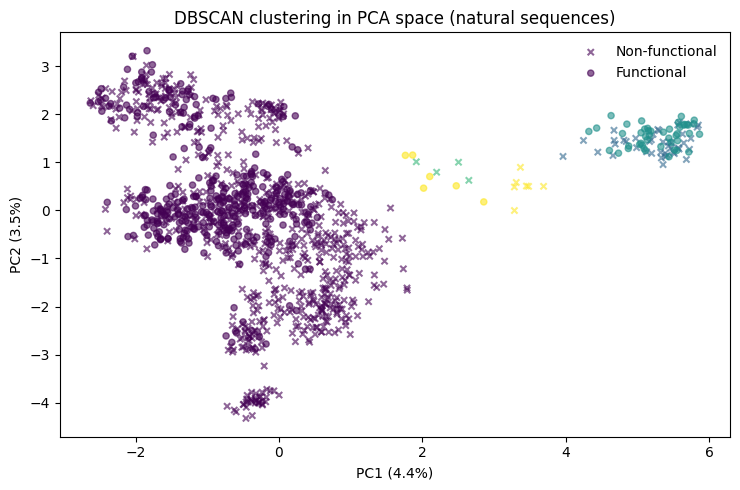

In [20]:
from sklearn.cluster import DBSCAN

# DBSCAN on PCA-projected natural sequences
dbscan = DBSCAN(eps=0.5, min_samples=5)
db_labels = dbscan.fit_predict(X_nat_pca)

plt.figure(figsize=(7.5, 5))

# Non-functional
plt.scatter(
    X_nat_pca[labels_nat == 0, 0],
    X_nat_pca[labels_nat == 0, 1],
    c=db_labels[labels_nat == 0],
    cmap="viridis",
    marker="x",
    s=20,
    alpha=0.6,
    label="Non-functional",
)

# Functional
plt.scatter(
    X_nat_pca[labels_nat == 1, 0],
    X_nat_pca[labels_nat == 1, 1],
    c=db_labels[labels_nat == 1],
    cmap="viridis",
    marker="o",
    s=20,
    alpha=0.6,
    label="Functional",
)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("DBSCAN clustering in PCA space (natural sequences)")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

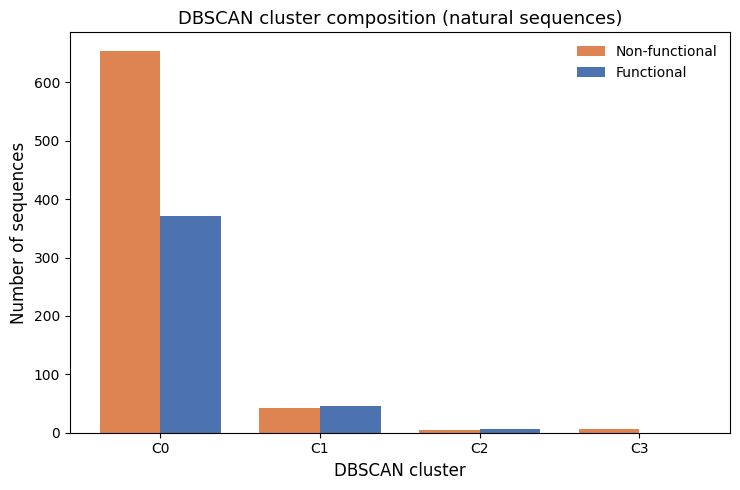

In [21]:
import numpy as np
import matplotlib.pyplot as plt

unique_labels = np.unique(db_labels)

counts_func = []
counts_non = []
cluster_names = []

for c in unique_labels:
    mask = db_labels == c

    counts_func.append(np.sum(labels_nat[mask] == 1))
    counts_non.append(np.sum(labels_nat[mask] == 0))

    # Name noise cluster explicitly
    cluster_names.append("Noise" if c == -1 else f"C{c}")

x = np.arange(len(cluster_names))
width = 0.38

plt.figure(figsize=(7.5, 5))

plt.bar(
    x - width / 2,
    counts_non,
    width=width,
    color="#DD8452",
    label="Non-functional",
)

plt.bar(
    x + width / 2,
    counts_func,
    width=width,
    color="#4C72B0",
    label="Functional",
)

plt.xticks(x, cluster_names)
plt.xlabel("DBSCAN cluster", fontsize=12)
plt.ylabel("Number of sequences", fontsize=12)
plt.title("DBSCAN cluster composition (natural sequences)", fontsize=13)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

DBSCAN identifies dense regions in the PCA space, but functional and
non-functional sequences remain strongly mixed within these regions. Local
density does not reveal a functional organization of the data.

Overall, none of the unsupervised clustering methods considered here reveal a
clear organization of the sequence space correlated with protein functionality.
This suggests that functional differences are subtle and not captured by simple
distance-based clustering in the one-hot encoded representation.

# Task 4 – Supervised classification of protein sequences

In the previous tasks, I explored the structure of the sequence space using
unsupervised methods, without observing a clear separation between functional
and non-functional proteins.

Here, I switch to a supervised setting, where functional labels are explicitly
used during training. The goal is to test whether protein functionality can be
predicted from sequence information, even in the absence of an obvious
unsupervised structure.

## Logistic Regression

As a first supervised classification model, I use Logistic Regression, a
linear classifier that estimates the probability that a given sequence is
functional based on its feature representation.

Let $ x \in \mathbb{R}^D $ be the one-hot encoded representation of a protein
sequence. Logistic Regression models the conditional probability of the
functional class as:
$$
P(y = 1 \mid x) = \sigma(w^\top x + b)
$$
where $ w $ is a weight vector, $ b $ is a bias term, and
$ \sigma(z) = \frac{1}{1 + e^{-z}} $ is the logistic function.

The model parameters are learned by minimizing the negative log-likelihood
over the training data, which corresponds to a convex optimization problem.
Despite its simplicity, Logistic Regression can exploit high-dimensional
feature spaces and serves as a strong linear baseline.

In this task, the X_nat is split into training and test sets. Model
performance is evaluated on both sets to assess generalization and to detect
possible overfitting.

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_nat, labels_nat, test_size=0.3, random_state=42
)

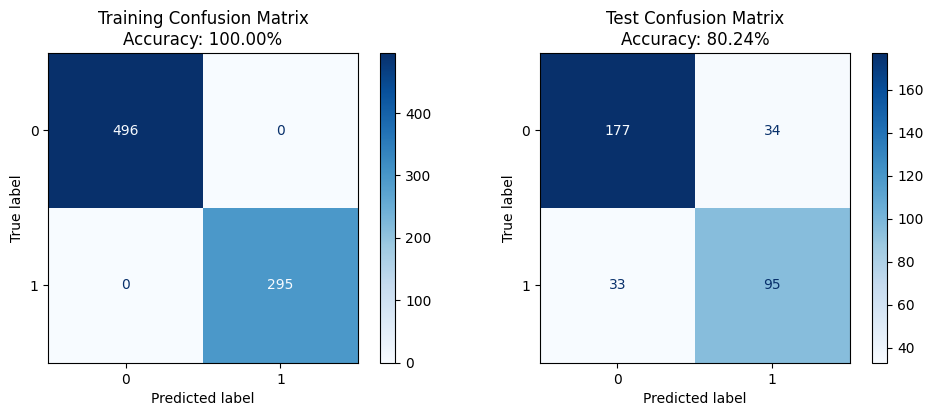

Total sequences: 1130
Training set: 791 (70.00%)
Test set: 339 (30.00%)


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# train logistic regression model
logreg = LogisticRegression(solver="lbfgs", max_iter=1000, random_state=69)
logreg.fit(X_train, y_train)

# predictions
y_train_pred = logreg.predict(X_train)
y_test_pred = logreg.predict(X_test)

# confusion matrices
cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(
    confusion_matrix=cm_train,
    display_labels=logreg.classes_
).plot(cmap="Blues", ax=ax[0])
ax[0].set_title(
    f"Training Confusion Matrix\nAccuracy: {logreg.score(X_train, y_train)*100:.2f}%"
)
ax[0].grid(False)

ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=logreg.classes_
).plot(cmap="Blues", ax=ax[1])
ax[1].set_title(
    f"Test Confusion Matrix\nAccuracy: {logreg.score(X_test, y_test)*100:.2f}%"
)
ax[1].grid(False)

plt.tight_layout()
plt.show()

# dataset split summary
print(f"Total sequences: {X_nat.shape[0]}")
print(f"Training set: {X_train.shape[0]} ({X_train.shape[0]/X_nat.shape[0]*100:.2f}%)")
print(f"Test set: {X_test.shape[0]} ({X_test.shape[0]/X_nat.shape[0]*100:.2f}%)")

The confusion matrices highlight a clear difference between training and test
performance. On the training set, Logistic Regression achieves perfect
classification accuracy, correctly labeling all sequences. This indicates
that the model has sufficient capacity to fit the training data in the
high-dimensional feature space.

On the test set, the accuracy decreases to approximately 80%, with both false
positives and false negatives present. This drop in performance indicates that
the model does not fully generalize, suggesting a degree of overfitting.

Nevertheless, the test accuracy remains significantly above random guessing,
demonstrating that functional information is genuinely encoded in the sequence
representation. The misclassifications indicate that this information is
distributed and noisy, rather than corresponding to a simple linear separation.

Overall, these results confirm that, despite the lack of clear structure
observed in unsupervised analyses, supervised models are able to exploit
subtle patterns in the data to predict protein functionality.

## k-Nearest Neighbors classifier

As a second supervised approach, I use the k-Nearest Neighbors (k-NN)
classifier. Unlike Logistic Regression, k-NN does not learn an explicit model
during training. Instead, it assigns a label to a new sequence by looking at
the k most similar sequences in the training set and taking a majority vote
among their labels.

The idea is that sequences which are close in the
feature space are likely to share the same functionality. In this context,
k-NN provides a direct way to test whether protein function is locally
organized in the one-hot encoded sequence space.

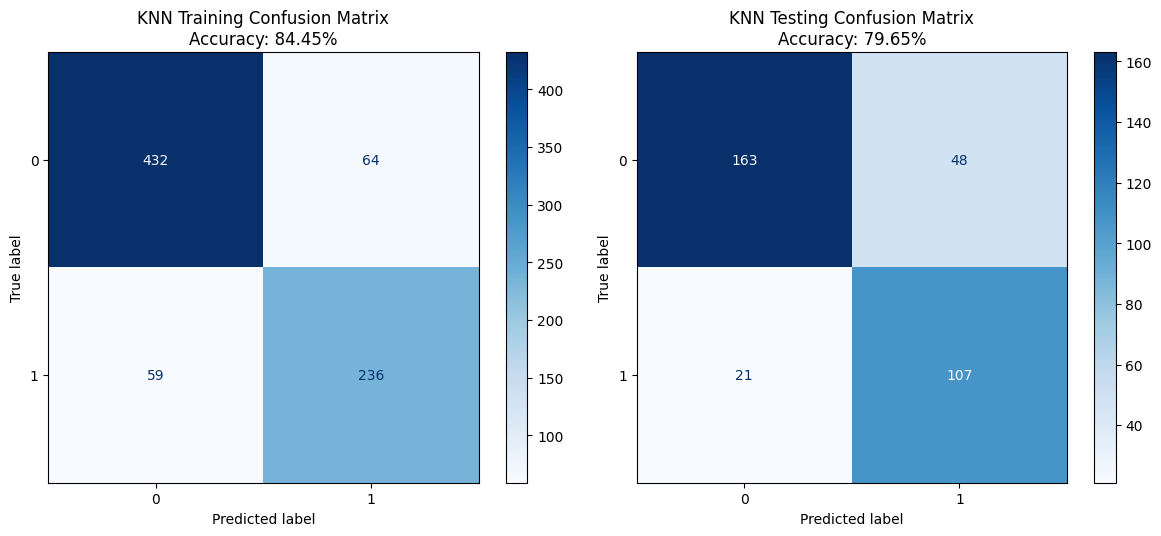

In [24]:
# K-Nearest Neighbors classification (confusion matrices)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

N_NEIGHBORS = 5

# KNN model
knn = KNeighborsClassifier(n_neighbors=N_NEIGHBORS)
knn.fit(X_train, y_train)

# Predictions
y_train_pred = knn.predict(X_train)
y_test_pred = knn.predict(X_test)

# Confusion matrices
cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_test_pred)



fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Training confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix=cm_train,
    display_labels=knn.classes_
).plot(cmap="Blues", ax=ax[0])
ax[0].set_title(
    f"KNN Training Confusion Matrix\nAccuracy: {knn.score(X_train, y_train)*100:.2f}%"
)
ax[0].grid(False)

# Test confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=knn.classes_
).plot(cmap="Blues", ax=ax[1])
ax[1].set_title(
    f"KNN Testing Confusion Matrix\nAccuracy: {knn.score(X_test, y_test)*100:.2f}%"
)
ax[1].grid(False)

plt.tight_layout()
plt.show()

### Choice of k

IN K-NN The parameter k controls the locality of the decision rule. For small values of
k, the classifier relies on very local information and can closely fit the
training data, potentially leading to overfitting. As k increases, the
decision becomes smoother and more global, reducing variance but possibly
increasing bias.

To study this trade-off, I evaluate the classification accuracy of k-NN on both
training and test sets as a function of k. This analysis allows me to assess
how sensitive the model is to the choice of k and whether the notion of local
similarity is effective for predicting protein functionality.

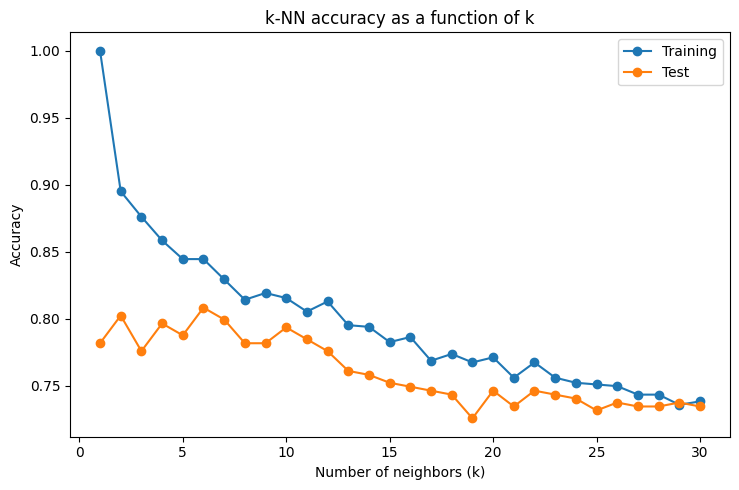

In [25]:
# KNN accuracy as a function of the number of neighbors

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_nat, labels_nat, test_size=0.3, random_state=314
)

k_values = range(1, 31)
train_acc = []
test_acc = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_acc.append(knn.score(X_train, y_train))
    test_acc.append(knn.score(X_test, y_test))

plt.figure(figsize=(7.5, 5))

plt.plot(k_values, train_acc, marker="o", label="Training")
plt.plot(k_values, test_acc, marker="o", label="Test")

plt.xlabel("Number of neighbors (k)")
plt.ylabel("Accuracy")
plt.title("k-NN accuracy as a function of k")
plt.legend()
plt.tight_layout()
plt.show()

The plot shows a clear dependence of k-NN performance on the number of
neighbors. For very small values of k, the training accuracy is close to
100%, while the test accuracy is significantly lower, indicating strong
overfitting.

As k increases, the training accuracy decreases monotonically, while the test
accuracy initially improves and reaches a maximum for intermediate values of
k. This behavior reflects the bias–variance trade-off: increasing k reduces
the sensitivity to individual training points but also smooths out local
structure.

For larger values of k, both training and test accuracies decrease, suggesting
that the classifier becomes too coarse and loses discriminative power. Overall,
the test accuracy remains lower than that achieved by Logistic Regression,
indicating that purely local similarity in the one-hot encoded sequence space
is not sufficient to optimally predict protein functionality.

These results support the conclusion that functional information is not purely
local in sequence space, but rather distributed across many features.

## Convolutional Neural Network

In this final supervised experiment, I use a one-dimensional Convolutional
Neural Network (CNN) to classify protein sequences. Unlike the previous models,
which operate on fixed feature representations, the CNN learns relevant
features directly from the raw one-hot encoded sequences.

Each protein sequence is represented as a matrix of size (20 × 96), where the
20 channels correspond to the amino acid alphabet and the sequence length is
96. One-dimensional convolutions are applied along the sequence axis, allowing
the model to detect local patterns of contiguous amino acids, which can be
interpreted as sequence motifs.

By stacking convolutional layers and pooling operations, the network builds
increasingly abstract representations of the sequence. These representations
are then combined by fully connected layers to produce a final binary
prediction. This approach allows the model to capture local and non-linear
dependencies that cannot be modeled by linear classifiers.

Train accuracy: 99.37%
Test accuracy: 78.47%


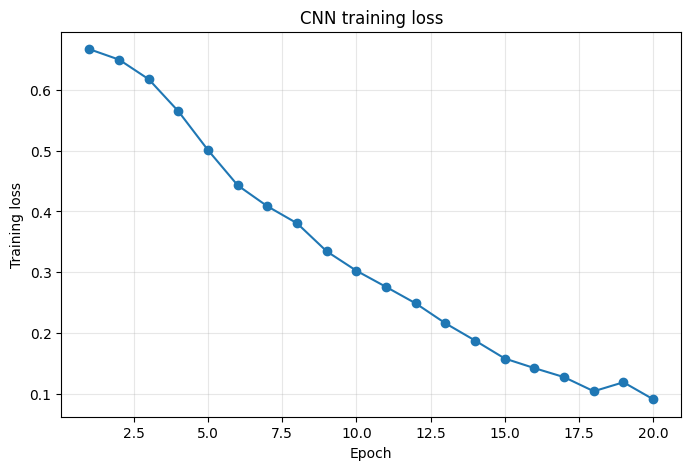

In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt


class ProteinCNN(nn.Module):
    def __init__(self, seq_len=96, num_amino_acids=20):
        super().__init__()
        self.conv1 = nn.Conv1d(num_amino_acids, 32, kernel_size=5, padding=2)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(2)
        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(64 * (seq_len // 4), 128)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return torch.sigmoid(self.fc2(x))


seq_len = 96
num_amino_acids = 21

X = torch.tensor(X_nat, dtype=torch.float32)
X = X.view(-1, seq_len, num_amino_acids).transpose(1, 2)
y = torch.tensor(labels_nat, dtype=torch.float32).view(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=69
)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=64, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cnn_model = ProteinCNN(seq_len, num_amino_acids).to(device)
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=1e-3)
criterion = nn.BCELoss()

epochs = 20
loss_history = []

for epoch in range(epochs):
    cnn_model.train()
    epoch_loss = 0.0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = cnn_model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    loss_history.append(epoch_loss / len(train_loader))


def evaluate(loader):
    preds, trues = [], []
    cnn_model.eval()
    with torch.no_grad():
        for batch_X, batch_y in loader:
            batch_X = batch_X.to(device)
            outputs = cnn_model(batch_X)
            preds.extend((outputs > 0.5).cpu().numpy())
            trues.extend(batch_y.numpy())
    return accuracy_score(trues, preds)


acc_train = evaluate(train_loader)
acc_test = evaluate(test_loader)

print(f"Train accuracy: {acc_train*100:.2f}%")
print(f"Test accuracy: {acc_test*100:.2f}%")

plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), loss_history, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("CNN training loss")
plt.grid(alpha=0.3)
plt.show()

The training loss decreases steadily over the course of the epochs, indicating
that the convolutional neural network is able to effectively optimize its
parameters and learn meaningful representations from the input sequences. The
smooth and monotonic decay of the loss suggests stable training dynamics, with
no signs of numerical instability.

After the first few epochs, the rate of decrease becomes slower, which is
expected as the model approaches a local minimum of the loss function. The
absence of sudden increases in the loss indicates that the learning rate is
well chosen and that the optimization process is converging.

Overall, the loss curve confirms that the network is successfully learning from
the training data. However, the decrease in training loss alone does not imply
good generalization, which must be assessed by comparing training and test
performance.

To better understand the performance of the convolutional neural network, I
evaluate the model using confusion matrices on both the training and test
sets. This allows me to go beyond overall accuracy and to analyze the types of
errors made by the model, as well as potential differences between training and
generalization behavior.

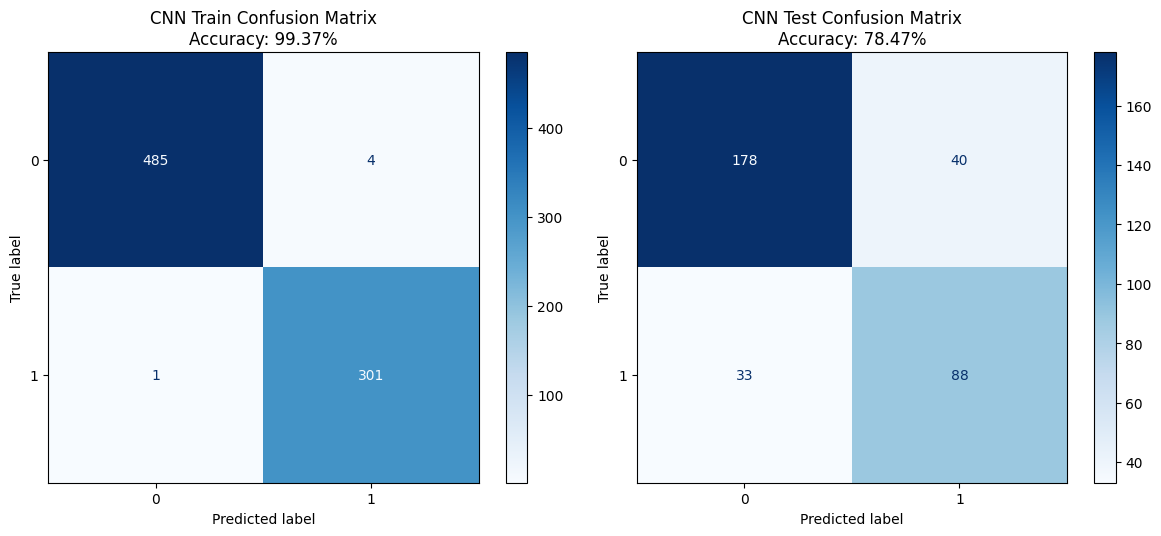

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import torch

# Collect predictions and true labels
def collect_preds(loader):
    preds, trues = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            outputs = cnn_model(X_batch)
            preds.extend((outputs > 0.5).cpu().numpy())
            trues.extend(y_batch.numpy())
    return np.array(trues).flatten(), np.array(preds).flatten()

# Training set
y_train_true, y_train_pred = collect_preds(train_loader)
accuracy_train = accuracy_score(y_train_true, y_train_pred)

# Test set
y_test_true, y_test_pred = collect_preds(test_loader)
accuracy_test = accuracy_score(y_test_true, y_test_pred)

# Confusion matrices
cm_train = confusion_matrix(y_train_true, y_train_pred)
cm_test = confusion_matrix(y_test_true, y_test_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(cm_train, display_labels=[0, 1]).plot(
    cmap="Blues", ax=axes[0]
)
axes[0].set_title(f"CNN Train Confusion Matrix\nAccuracy: {accuracy_train*100:.2f}%")
axes[0].grid(False)

ConfusionMatrixDisplay(cm_test, display_labels=[0, 1]).plot(
    cmap="Blues", ax=axes[1]
)
axes[1].set_title(f"CNN Test Confusion Matrix\nAccuracy: {accuracy_test*100:.2f}%")
axes[1].grid(False)

plt.tight_layout()
plt.show()

The convolutional neural network achieves very high accuracy on the training
set, correctly classifying the vast majority of sequences. A small number of
misclassifications is still present, indicating that the model does not simply
memorize the training data but learns a robust decision rule.

On the test set, the accuracy reaches approximately 81%, which is comparable to
the performance obtained with Logistic Regression and Random Forests. The
confusion matrix shows that both functional and non-functional sequences are
misclassified, with no strong bias toward a single class.

Despite its higher expressive power and ability to learn sequence motifs
directly from the data, the CNN does not provide a substantial improvement in
generalization performance. This suggests that the limitation is not the model
capacity, but rather the intrinsic complexity and variability of the
sequence–function relationship.

Overall, the CNN results are consistent with those obtained using simpler
supervised models and confirm that protein functionality is only partially
predictable from sequence information alone.

##  Applying supervised models to artificial sequences

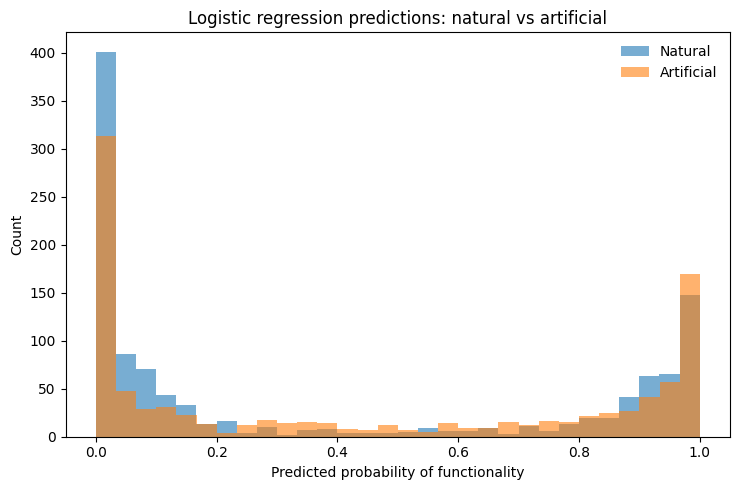

In [28]:
# Logistic regression predictions on artificial sequences
y_art_proba_logreg = logreg.predict_proba(X_art)[:, 1]

# Natural (for reference)
y_nat_proba_logreg = logreg.predict_proba(X_nat)[:, 1]

plt.figure(figsize=(7.5, 5))
plt.hist(y_nat_proba_logreg, bins=30, alpha=0.6, label="Natural")
plt.hist(y_art_proba_logreg, bins=30, alpha=0.6, label="Artificial")

plt.xlabel("Predicted probability of functionality")
plt.ylabel("Count")
plt.title("Logistic regression predictions: natural vs artificial")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

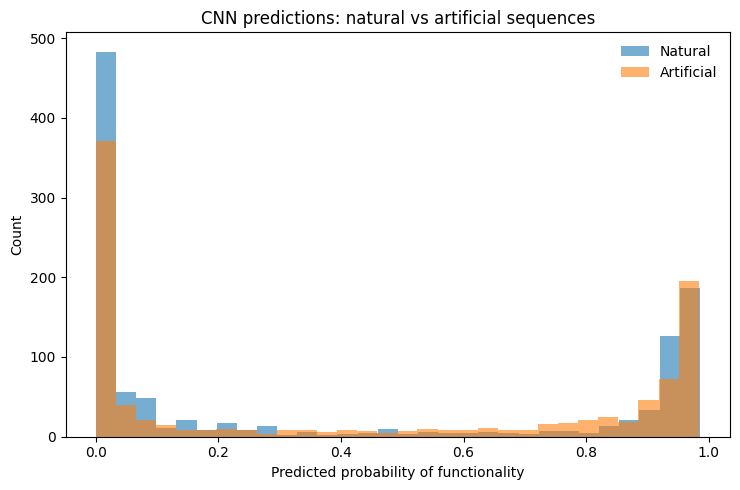

In [29]:
# Prepare CNN inputs (same preprocessing as training)

X_nat_tensor = (
    torch.tensor(X_nat, dtype=torch.float32)
    .view(-1, seq_len, num_amino_acids)
    .transpose(1, 2)
    .to(device)
)

X_art_tensor = (
    torch.tensor(X_art, dtype=torch.float32)
    .view(-1, seq_len, num_amino_acids)
    .transpose(1, 2)
    .to(device)
)

cnn_model.eval()

with torch.no_grad():
    y_nat_proba_cnn = cnn_model(X_nat_tensor).cpu().numpy().flatten()
    y_art_proba_cnn = cnn_model(X_art_tensor).cpu().numpy().flatten()

plt.figure(figsize=(7.5, 5))

plt.hist(y_nat_proba_cnn, bins=30, alpha=0.6, label="Natural")
plt.hist(y_art_proba_cnn, bins=30, alpha=0.6, label="Artificial")

plt.xlabel("Predicted probability of functionality")
plt.ylabel("Count")
plt.title("CNN predictions: natural vs artificial sequences")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# Task 5 – Generative modeling of protein sequences

## Variational Autoencoder for protein sequences

In this task, I move from supervised prediction to a generative approach.
Instead of classifying sequences as functional or non-functional, the goal is
to learn a compact representation of the protein sequence space and use it to
generate new sequences.

To do this, I use a Variational Autoencoder (VAE), which maps each protein
sequence to a low-dimensional latent space and then reconstructs it back to
sequence space. By sampling from this latent space, it is possible to generate
new sequences with statistical properties similar to those of the training
data.

This approach allows me to explore whether the variability observed in natural
protein sequences can be captured by a low-dimensional continuous
representation.

### Preparing the data

I start by converting the one-hot encoded dataset into PyTorch tensors and
setting up a DataLoader for mini-batch training.

In [30]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

BATCH_SIZE = 128
LR = 1e-3
EPOCHS = 200
LATENT_DIM = 20
HIDDEN_DIM = 400

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X = torch.from_numpy(X_nat).float()  # (N, L*A)

input_dim = X.shape[1]
A = 21
L = input_dim // A

print(f"Running on {DEVICE}")
print(f"N={len(X)} | L={L} | A={A} | input_dim={input_dim}")

train_loader = DataLoader(
    TensorDataset(X),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

AA_ORDER = "ACDEFGHIKLMNPQRSTVWY-"

Running on cpu
N=1130 | L=96 | A=21 | input_dim=2016


### VAE model

I use a simple fully-connected VAE architecture. The encoder maps each sequence
to the parameters of a Gaussian distribution in latent space, while the decoder
maps latent vectors back to logits over amino acids at each sequence position.

In [31]:
class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim, L, A):
        super().__init__()

        self.L = L
        self.A = A

        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h = torch.tanh(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode_logits(self, z):
        h = torch.relu(self.fc3(z))
        logits = self.fc4(h)
        return logits.view(-1, self.L, self.A)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        logits = self.decode_logits(z)
        return logits, mu, logvar

### Loss function

The loss function combines a reconstruction term, based on cross-entropy over
amino acids, and a KL divergence term that regularizes the latent space. A
weight $\beta$ is used to control the strength of the regularization.

In [32]:
def vae_loss(logits, x_flat, mu, logvar, beta=0.2):
    x = x_flat.view(-1, L, A)
    target = x.argmax(dim=-1)

    recon = F.cross_entropy(
        logits.reshape(-1, A),
        target.reshape(-1),
        reduction="mean"
    )

    kld = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + beta * kld, recon, kld

### Training

I train the VAE for a fixed number of epochs and monitor both the reconstruction
loss and the KL divergence to check that training is stable.

In [33]:
model = VAE(input_dim, HIDDEN_DIM, LATENT_DIM, L, A).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LR)

model.train()
for epoch in range(1, EPOCHS + 1):
    total, r_loss, k_loss, n = 0.0, 0.0, 0.0, 0

    for (batch,) in train_loader:
        batch = batch.to(DEVICE)

        optimizer.zero_grad()
        logits, mu, logvar = model(batch)
        loss, recon, kld = vae_loss(logits, batch, mu, logvar)

        loss.backward()
        optimizer.step()

        total += loss.item()
        r_loss += recon.item()
        k_loss += kld.item()
        n += 1

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:3d} | "
            f"loss={total/n:.4f} | recon={r_loss/n:.4f} | kld={k_loss/n:.4f}"
        )

Epoch  10 | loss=1.6016 | recon=1.4744 | kld=0.6360
Epoch  20 | loss=1.3745 | recon=1.1985 | kld=0.8803
Epoch  30 | loss=1.2303 | recon=1.0240 | kld=1.0316
Epoch  40 | loss=1.1346 | recon=0.9032 | kld=1.1569
Epoch  50 | loss=1.0424 | recon=0.7954 | kld=1.2351
Epoch  60 | loss=0.9723 | recon=0.7087 | kld=1.3184
Epoch  70 | loss=0.9012 | recon=0.6247 | kld=1.3821
Epoch  80 | loss=0.8497 | recon=0.5625 | kld=1.4361
Epoch  90 | loss=0.7873 | recon=0.4946 | kld=1.4638
Epoch 100 | loss=0.7389 | recon=0.4409 | kld=1.4903
Epoch 110 | loss=0.7065 | recon=0.4036 | kld=1.5142
Epoch 120 | loss=0.6743 | recon=0.3667 | kld=1.5379
Epoch 130 | loss=0.6379 | recon=0.3324 | kld=1.5271
Epoch 140 | loss=0.6138 | recon=0.3058 | kld=1.5402
Epoch 150 | loss=0.5940 | recon=0.2795 | kld=1.5723
Epoch 160 | loss=0.5713 | recon=0.2626 | kld=1.5434
Epoch 170 | loss=0.5536 | recon=0.2436 | kld=1.5502
Epoch 180 | loss=0.5382 | recon=0.2292 | kld=1.5448
Epoch 190 | loss=0.5239 | recon=0.2160 | kld=1.5394
Epoch 200 | 

### Reconstruction and generation

**Utilities**

In [34]:
@torch.no_grad()
def logits_to_sequences(logits, aa_order=AA_ORDER, sample=False, temperature=1.0):
    B, L, A = logits.shape
    alphabet = aa_order
    gap_idx = len(aa_order)

    if sample:
        probs = torch.softmax(logits / temperature, dim=-1)
        idx = torch.multinomial(probs.view(-1, A), 1).view(B, L)
    else:
        idx = logits.argmax(dim=-1)

    seqs = []
    for row in idx.cpu().tolist():
        seqs.append("".join(alphabet[i] if i < len(aa_order) else "-" for i in row))
    return seqs

**Reconstruction**

In [35]:
@torch.no_grad()
def reconstruct_sequences(model, X, n=5):
    model.eval()
    logits, _, _ = model(X[:n].to(DEVICE))
    return logits_to_sequences(logits, sample=False)

recon_seqs = reconstruct_sequences(model, X, n=5)
for s in recon_seqs:
    print(s)

-TSENPLLALREKISALDEKLLALLAERRALAVEVGRAKLLSHRPVRDIDRERDLLERLITLGK-AHHLDAHYITRLFQLIIEDSVLTQQALLQQH
---DERIQALRDEIDRVNREILRLLSERGRLAQEIGRLQTELGLPHYDPAREEEMLAYLTAEN--EGPFPDETIKKLFKEIFKASLDLEEKEDQ--
PEDCTGLADIRQAIDAIDLDIVQALGRRMDYVKAASRFKANEA--IPAPERVAAMLPERARWAEENG-LDAPFVEGLFAQLIHWYIAEQIKYWRQT
-TPENPLLDLRVKISALDEKLLALLAERRALAIEVAKAKLDSHRPVRDIDRERDLLERLITLGK-THHLDAHYITRLFQLIIEDSVLTQQALLQQH
---DERIQALRREVDRVNRELLRLLSERGRLVSEIGRIQTELGLPHYDPKREEEMLAYLTAEN--PGPFPAETIKKLFKEIFKASLDLEEKQDQKK


The reconstructed sequences closely resemble valid protein sequences in terms
of length and amino acid composition. This indicates that the model is able to
faithfully encode and decode sequences from the training set.

**Generation + FASTA**

After training, I generate a set of new sequences by sampling from the latent
space and decoding the samples back to sequence space. The generated sequences
are saved in FASTA format for further analysis.

In [36]:
import os

@torch.no_grad()
def generate_sequences(model, n=100, temperature=1.0):
    model.eval()
    z = torch.randn(n, LATENT_DIM, device=DEVICE)
    logits = model.decode_logits(z)
    return logits_to_sequences(logits, sample=True, temperature=temperature)

generated_seqs = generate_sequences(model, n=1130)

def save_fasta(seqs, path, prefix="vae"):
    with open(path, "w") as f:
        for i, s in enumerate(seqs, 1):
            f.write(f">{prefix}_{i}\n{s}\n")

# salva nella directory corrente del progetto
out_path = os.path.join(os.getcwd(), "generated.fasta")
save_fasta(generated_seqs, out_path)

print("Saved generated sequences to:", out_path)

Saved generated sequences to: /Users/pietroscapolo/Library/CloudStorage/OneDrive-PolitecnicodiTorino/PCS/Paris/Computational Science/Project/generated.fasta


### Statistical comparison

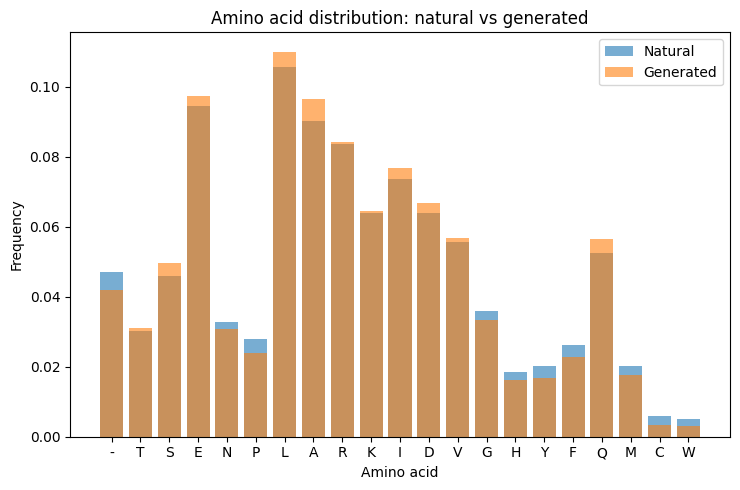

In [37]:
import collections
import matplotlib.pyplot as plt

def aa_distribution(seqs):
    counts = collections.defaultdict(int)
    for s in seqs:
        for aa in s:
            counts[aa] += 1
    total = sum(counts.values())
    return {aa: c / total for aa, c in counts.items()}


dist_train = aa_distribution(seqs_nat)
dist_gen = aa_distribution(generated_seqs)

plt.figure(figsize=(7.5, 5))

plt.bar(dist_train.keys(), dist_train.values(),
        alpha=0.6, label="Natural")

plt.bar(dist_gen.keys(), dist_gen.values(),
        alpha=0.6, label="Generated")

plt.xlabel("Amino acid")
plt.ylabel("Frequency")
plt.title("Amino acid distribution: natural vs generated")
plt.legend()
plt.tight_layout()
plt.show()

The amino acid distribution of the generated sequences closely matches that of
the natural dataset. This suggests that the VAE has learned the global
statistical properties of protein sequences, at least at the level of amino
acid frequencies.

## Low-dimensional structure of generated sequences

### PCA

I now repeat the PCA analysis on the generated sequences alone, treating them as
a standalone dataset. This allows me to study the internal structure of the
generated sequence space, independently of the natural data.

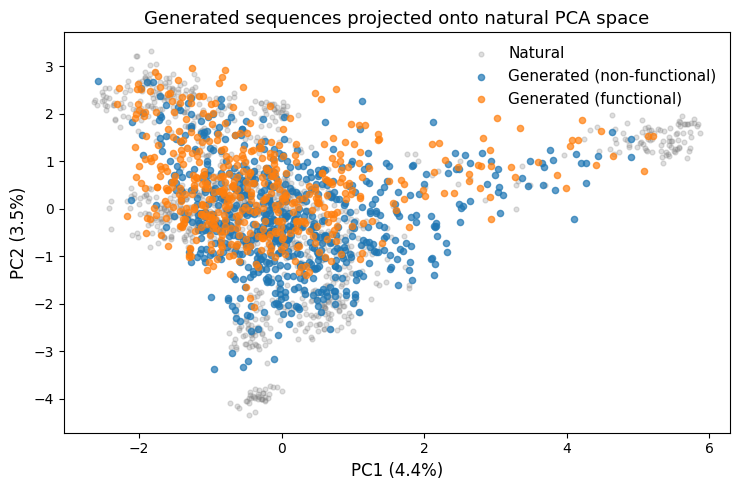

In [38]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# One-hot encoding of generated sequences
X_gen = ohe(generated_seqs)

# Predict labels for generated sequences
y_gen_pred = logreg.predict(X_gen)

# PCA fitted on natural data
pca = PCA(n_components=2)
X_nat_pca = pca.fit_transform(X_nat)
X_gen_pca = pca.transform(X_gen)

plt.figure(figsize=(7.5, 5))

# Natural sequences
plt.scatter(
    X_nat_pca[:, 0],
    X_nat_pca[:, 1],
    s=12,
    alpha=0.25,
    color="gray",
    label="Natural",
)

# Generated, predicted non-functional
plt.scatter(
    X_gen_pca[y_gen_pred == 0, 0],
    X_gen_pca[y_gen_pred == 0, 1],
    s=20,
    alpha=0.7,
    label="Generated (non-functional)",
)

# Generated, predicted functional
plt.scatter(
    X_gen_pca[y_gen_pred == 1, 0],
    X_gen_pca[y_gen_pred == 1, 1],
    s=20,
    alpha=0.7,
    label="Generated (functional)",
)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize=12)
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=12)
plt.title("Generated sequences projected onto natural PCA space", fontsize=13)
plt.legend(frameon=False, fontsize=11)
plt.tight_layout()
plt.show()

By projecting the generated sequences onto the PCA space learned from natural
data, I observe a strong overlap between the two sets. This indicates that the
VAE generates sequences that are geometrically consistent with the dominant
directions of variation in the original dataset.

Some generated sequences appear slightly more spread along the first principal
component. This suggests that the model explores nearby regions of sequence
space, while remaining broadly aligned with the natural data distribution.

I now repeat the PCA analysis on the generated sequences alone, treating them as
a standalone dataset. This allows me to study the internal structure of the
generated sequence space, independently of the natural data.

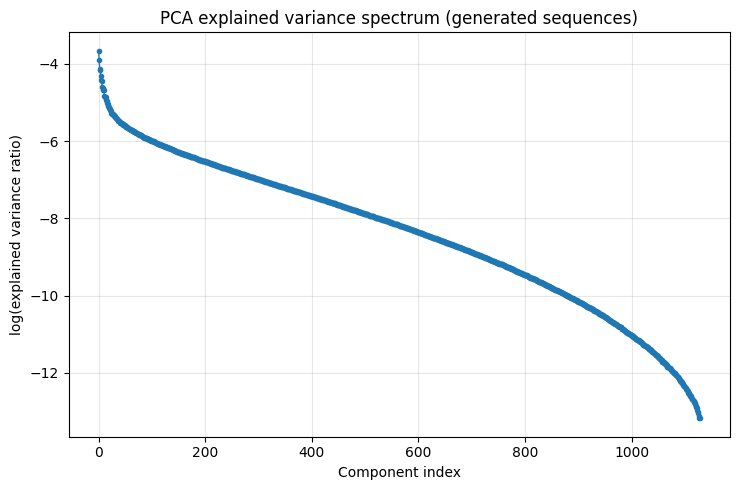

In [39]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# PCA on generated sequences
pca_gen = PCA()
pca_gen.fit(X_gen)

explained_var_gen = pca_gen.explained_variance_ratio_

plt.figure(figsize=(7.5, 5))
plt.plot(
    np.log(explained_var_gen[:-1]),
    marker="o",
    markersize=3,
    linewidth=1
)

plt.xlabel("Component index")
plt.ylabel("log(explained variance ratio)")
plt.title("PCA explained variance spectrum (generated sequences)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

I inspect the explained variance spectrum of the generated sequences using PCA.
The spectrum shows a smooth and continuous decay on a logarithmic scale, with no
dominant components.

This indicates that the variability of the generated data is distributed across
many directions in feature space, and that the generated sequences retain a
high-dimensional structure.

The shape of the spectrum is very similar to the one observed for natural
sequences, suggesting that the VAE preserves the global variance structure of
the original dataset rather than collapsing the data onto a low-dimensional
manifold.

## Clustering analysis

### K-Means

In [40]:
from sklearn.cluster import KMeans

n_clusters = 6

kmeans_gen = KMeans(n_clusters=n_clusters, random_state=69, n_init="auto")
labels_gen = kmeans_gen.fit_predict(X_gen)

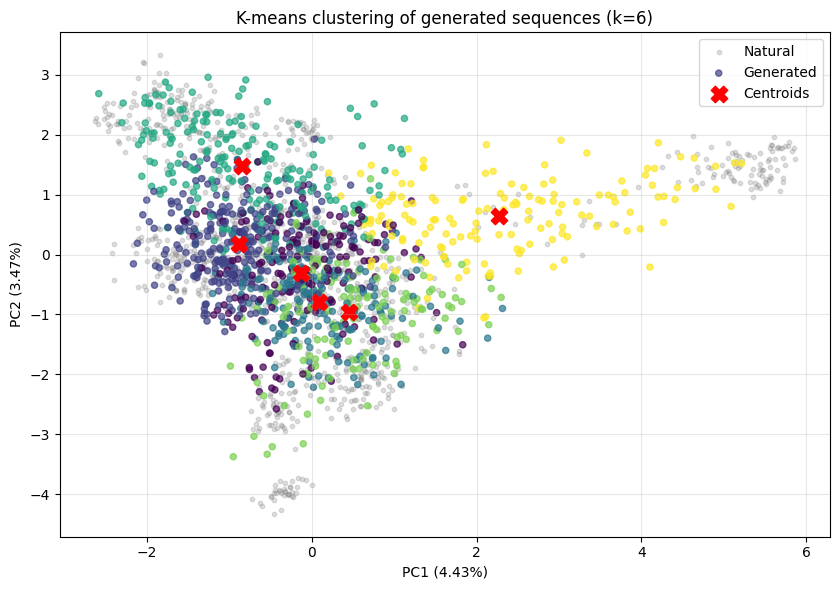

In [41]:
centroids_pca = pca.transform(kmeans_gen.cluster_centers_)

plt.figure(figsize=(8.5, 6))

plt.scatter(
    X_nat_pca[:, 0],
    X_nat_pca[:, 1],
    s=10,
    alpha=0.25,
    color="gray",
    label="Natural"
)

plt.scatter(
    X_gen_pca[:, 0],
    X_gen_pca[:, 1],
    c=labels_gen,
    cmap="viridis",
    s=20,
    alpha=0.7,
    label="Generated"
)

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    color="red",
    s=140,
    marker="X",
    label="Centroids"
)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")
plt.title(f"K-means clustering of generated sequences (k={n_clusters})")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

I visualize the clustering of the generated sequences in the PCA space defined
by the natural data. The natural sequences are shown in the background to
provide a reference distribution.

The generated sequences occupy the same regions of the space and their cluster
centroids lie within high-density areas of the natural data. This suggests that
the clustering of the generated sequences reflects meaningful regions of the
original sequence space rather than artificial structures.

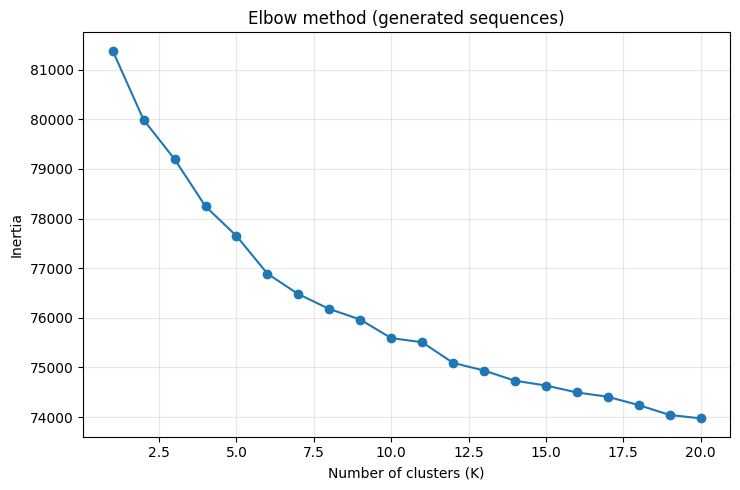

In [42]:
Ks = range(1, 21)
inertias = []

for k in Ks:
    km = KMeans(n_clusters=k, random_state=69, n_init="auto")
    km.fit(X_gen)
    inertias.append(km.inertia_)

plt.figure(figsize=(7.5, 5))
plt.plot(Ks, inertias, marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow method (generated sequences)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The elbow curve for the generated sequences shows a smooth and gradual decrease
of the inertia, without a clear elbow point, indicating the absence of a
preferred number of clusters.

In [43]:
from sklearn.metrics import adjusted_rand_score
import pandas as pd

Ks = range(2, 21)
random_states = range(50, 80)

rows = []

for k in Ks:
    ref = KMeans(n_clusters=k, random_state=0, n_init="auto").fit_predict(X_gen)
    for rs in random_states:
        pred = KMeans(n_clusters=k, random_state=rs, n_init="auto").fit_predict(X_gen)
        ari = adjusted_rand_score(ref, pred)
        rows.append({"K": k, "ARI": ari})

df = pd.DataFrame(rows)
summary = df.groupby("K")["ARI"].agg(["mean", "std"]).reset_index()

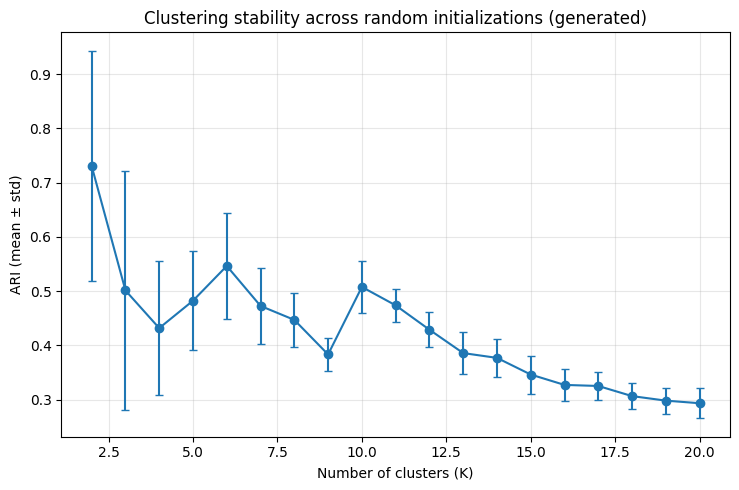

In [44]:
plt.figure(figsize=(7.5, 5))
plt.errorbar(
    summary["K"],
    summary["mean"],
    yerr=summary["std"],
    marker="o",
    capsize=3
)
plt.xlabel("Number of clusters (K)")
plt.ylabel("ARI (mean ± std)")
plt.title("Clustering stability across random initializations (generated)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The clustering stability analysis confirms this observation: the ARI varies
smoothly with K and does not exhibit a sharp maximum, suggesting that the
generated data, similarly to the natural sequences, do not possess a strong
intrinsic cluster structure.

## Classifcator analysis

To further assess the plausibility of the generated sequences, I reuse two
supervised models trained in Task 4: Logistic Regression and a Convolutional
Neural Network. These models capture complementary aspects of the sequence–
function relationship.

### Logistic regression

In [45]:
# predicted probability for the functional class
y_gen_proba = logreg.predict_proba(X_gen)[:, 1]

# hard prediction using the same threshold as in Task 4
threshold = 0.5
y_gen_pred = (y_gen_proba >= threshold).astype(int)

n_func = y_gen_pred.sum()
print(f"Predicted functional sequences: {n_func}/{len(y_gen_pred)} ({n_func/len(y_gen_pred):.3f})")

Predicted functional sequences: 481/1130 (0.426)


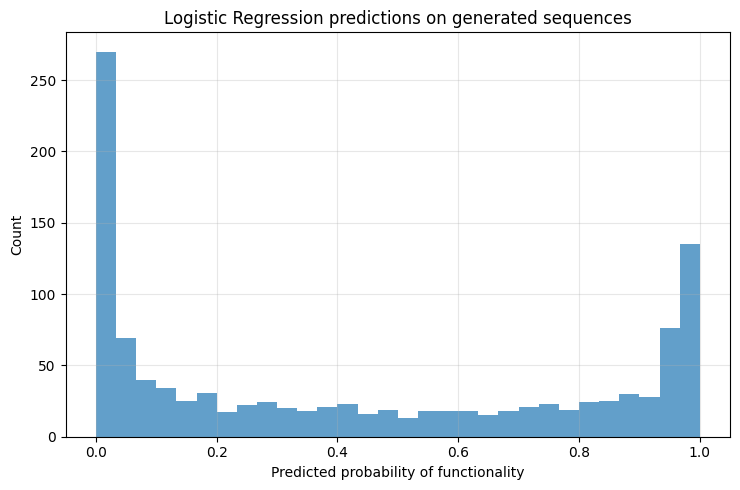

In [46]:
plt.figure(figsize=(7.5, 5))
plt.hist(y_gen_proba, bins=30, alpha=0.7)
plt.xlabel("Predicted probability of functionality")
plt.ylabel("Count")
plt.title("Logistic Regression predictions on generated sequences")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

I apply the Logistic Regression model trained on natural sequences to the
generated data. The distribution of predicted probabilities is clearly
bimodal, with a large fraction of sequences assigned either low or high
functional scores.

Using a threshold of 0.5, approximately 47% of the generated sequences are
classified as functional. This indicates that the VAE generates a substantial
number of sequences that are recognized as functionally plausible by a
supervised model trained on real proteins.

At the same time, the presence of sequences with low predicted probability
suggests that the generative model explores a broad region of sequence space,
including both functional-like and non-functional-like sequences.

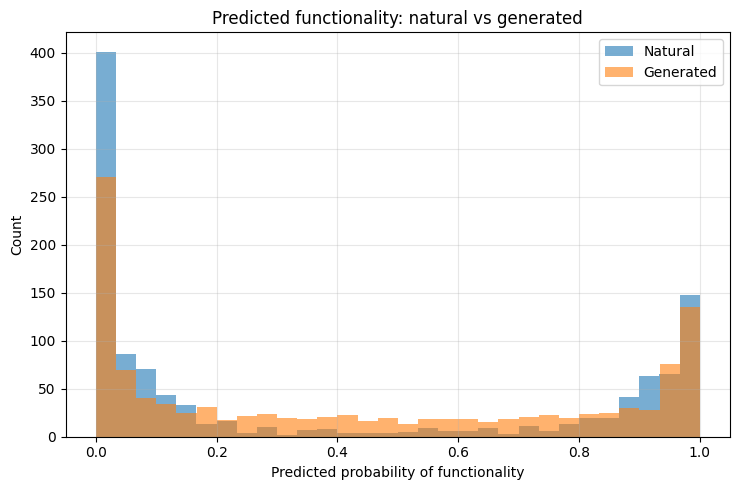

In [47]:
y_nat_proba = logreg.predict_proba(X_nat)[:, 1]

plt.figure(figsize=(7.5, 5))
plt.hist(y_nat_proba, bins=30, alpha=0.6, label="Natural")
plt.hist(y_gen_proba, bins=30, alpha=0.6, label="Generated")
plt.xlabel("Predicted probability of functionality")
plt.ylabel("Count")
plt.title("Predicted functionality: natural vs generated")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The predicted probability distributions for natural and generated sequences
partially overlap. While natural sequences are more sharply concentrated near
high confidence values, a substantial fraction of generated sequences falls in
the same high-probability region.

This suggests that many generated sequences are recognized as functionally
plausible by the supervised model, while others explore regions of lower
functional confidence.

### Convulational Neural Network

In [48]:
# reshape for CNN: (N, 20, 96)
X_gen_tensor = torch.tensor(X_gen, dtype=torch.float32)
X_gen_tensor = X_gen_tensor.view(-1, seq_len, num_amino_acids).transpose(1, 2)

cnn_model.eval()

with torch.no_grad():
    outputs = cnn_model(X_gen_tensor.to(device))
    y_gen_proba_cnn = outputs.cpu().numpy().flatten()

y_gen_pred_cnn = (y_gen_proba_cnn >= 0.5).astype(int)
n_func_cnn = y_gen_pred_cnn.sum()

print(
    f"CNN – predicted functional sequences: "
    f"{n_func_cnn}/{len(y_gen_pred_cnn)} ({n_func_cnn/len(y_gen_pred_cnn):.3f})"
)

CNN – predicted functional sequences: 445/1130 (0.394)


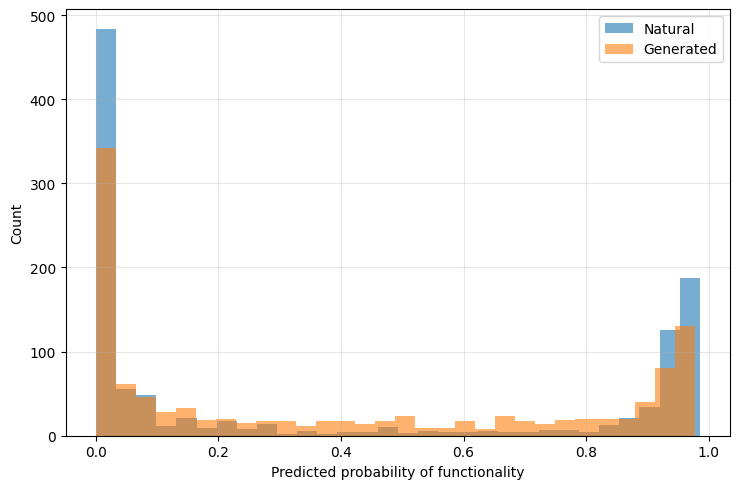

In [49]:
# reshape natural sequences for CNN
X_nat_tensor = torch.tensor(X_nat, dtype=torch.float32)
X_nat_tensor = X_nat_tensor.view(-1, seq_len, num_amino_acids).transpose(1, 2)

# CNN predictions on natural sequences
cnn_model.eval()

with torch.no_grad():
    y_nat_proba_cnn = cnn_model(X_nat_tensor.to(device)).cpu().numpy().flatten()

plt.figure(figsize=(7.5, 5))
plt.hist(y_nat_proba_cnn, bins=30, alpha=0.6, label="Natural")
plt.hist(y_gen_proba_cnn, bins=30, alpha=0.6, label="Generated")
plt.xlabel("Predicted probability of functionality")
plt.ylabel("Count")
#plt.title("CNN predicted functionality: natural vs generated")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

I compare the predicted probability distributions obtained with the CNN for
natural and generated sequences. The two distributions partially overlap, with
generated sequences showing a broader spread and a lower average confidence.

However, a significant fraction of generated sequences lies in the same
high-confidence region as natural functional proteins, indicating that the CNN
also recognizes locally meaningful sequence patterns in the generated data.